# 示例策略

演示 StrategyDef 框架的 notebook 用法

本 notebook 展示了一个基于均线交叉的简单交易策略：

1. __STRATEGY_META__ 元信息声明
2. MakeStrategy 子类 —— 重写 genSignal()
3. 直接构建策略对象

策略逻辑：当短期均线上穿长期均线时买入（信号=1），下穿时卖出（信号=-1）。

In [ ]:
import datetime as dt

import pandas as pd

from QuantStudio.Factor import FactorOperator as fo
from QuantStudio.Factor.BaoStockDB import BaoStockDB
from QuantStudio.BackTest.Strategy.Strategy import MakeStrategy


# ============================================================
# __STRATEGY_META__ — 模块元信息
# ============================================================
__STRATEGY_META__ = {
    # ---- 必填 ----
    "TargetTable": "strategy_signals_example",
    "IDType": "A股",
    "Description": "均线交叉策略示例：短期均线上穿长期均线买入，下穿卖出",

    # ---- 算子默认配置 ----
    "OperatorConfig": {
        "SignalType": "目标权重",
        "InitCash": 1e6,
        "ShortAllowed": False,
        "StartDT": dt.datetime(2024, 6, 5)
    },

    # ---- 依赖声明 ----
    # "FactorDeps": {
    #     "stock_cn_day_bar_nafilled": ["close"],
    # },
    "DBDeps": {"BSDB": "基于 BaoStock 的因子库，提供行情和基本信息等数据"},

    # ---- 可调参数 ----
    "ModelArgs": {
        "short_window": "短期均线窗口",
        "long_window": "长期均线窗口",
    },

    "Author": "示例作者",
    "Tags": ["示例", "均线", "趋势跟踪"],
    "MaxLookBack": 120,
}


# ============================================================
# MakeStrategy 子类
# ============================================================

class MACrossStrategy(MakeStrategy):
    """均线交叉策略

    信号逻辑：
      - ma_short > ma_long → 买入 (signal=1)
      - ma_short < ma_long → 卖出 (signal=-1)
      - 否则 → 不变 (signal=0)
    """

    def genSignal(self, f, idt, x, last_price, cash, position_num, args):
        """生成交易信号

        Args:
            f: 当前策略因子
            idt: 当前时点
            x: 输入的因子数据列表，x[0]=short_ma, x[1]=long_ma
            last_price: 最新价格
            cash: 现金
            position_num: 当前持仓数量
            args: 策略参数

        Returns:
            pd.Series: 信号值，索引为证券ID
        """
        short_ma = x[0].iloc[0]
        long_ma = x[1].iloc[0]
        
        signal = pd.Series(0, index=short_ma.index)
        signal[short_ma > long_ma] = 1
        signal[short_ma < long_ma] = -1

        return signal

In [2]:
# ============================================================
# 策略参数
# ============================================================
short_window = 5
long_window = 20
signal_type = __STRATEGY_META__["OperatorConfig"].get("SignalType", "目标权重")
init_cash = __STRATEGY_META__["OperatorConfig"].get("InitCash", 1e6)
short_allowed = __STRATEGY_META__["OperatorConfig"].get("ShortAllowed", False)
start_dt = __STRATEGY_META__["OperatorConfig"].get("StartDT", dt.datetime(2024, 6, 5))

# ============================================================
# 构建策略因子
# ============================================================

# 数据库连接
BSDB = BaoStockDB().connect()

# 获取收盘价
FT = BSDB.getTable("A股K线数据")
close = FT.getFactor("close")

# 计算短期和长期均线
ma_short = fo.RollingMean(window=short_window, min_periods=1)(close)
ma_long = fo.RollingMean(window=long_window, min_periods=1)(close)

# 构造策略实例（x_lookback 指定每个依赖因子的回溯期数）
makeStrategy = MACrossStrategy(
    signal_type=signal_type,
    init_cash=init_cash,
    short_allowed=short_allowed,
    start_dt=start_dt,
    x_lookback=[0, 0],
    x_section_ids=[None, None],
)

# 调用策略算子，传入均线因子和价格因子
Strategy = makeStrategy(ma_short, ma_long, last_price=close)

login success!


---
## 交互式调试

以下 cell 无 `strategy-def` tag，框架加载时不会执行。
用于本地数据探索和可视化。

login success!


2026-09-02 16:12:26,516 | QS | 57092 | INFO : 开始初始化计算...
2026-09-02 16:12:26,516 | QS | 57092 | INFO : 初始化计算完成, 耗时 0.002933999989181757 秒
2026-09-02 16:12:26,516 | QS | 57092 | INFO : 开始准备计算...
2026-09-02 16:12:26,516 | QS | 57092 | INFO : 准备计算完成, 耗时 3.400025889277458e-06 秒
2026-09-02 16:12:26,516 | QS | 57092 | INFO : 开始正式计算...
2026-09-02 16:12:28,132 | QS | 57092 | INFO : 正式计算完成, 耗时 1.6067551999585703 秒


,绝对表现
起始时点,2024-06-05
结束时点,2024-12-31
时点数,142
总收益率,2.20%
年化收益率,3.88%
年化波动率,35.86%
Sharpe比率,0.11
收益风险比,0.11
胜率,68.31%
最大回撤率,23.92%

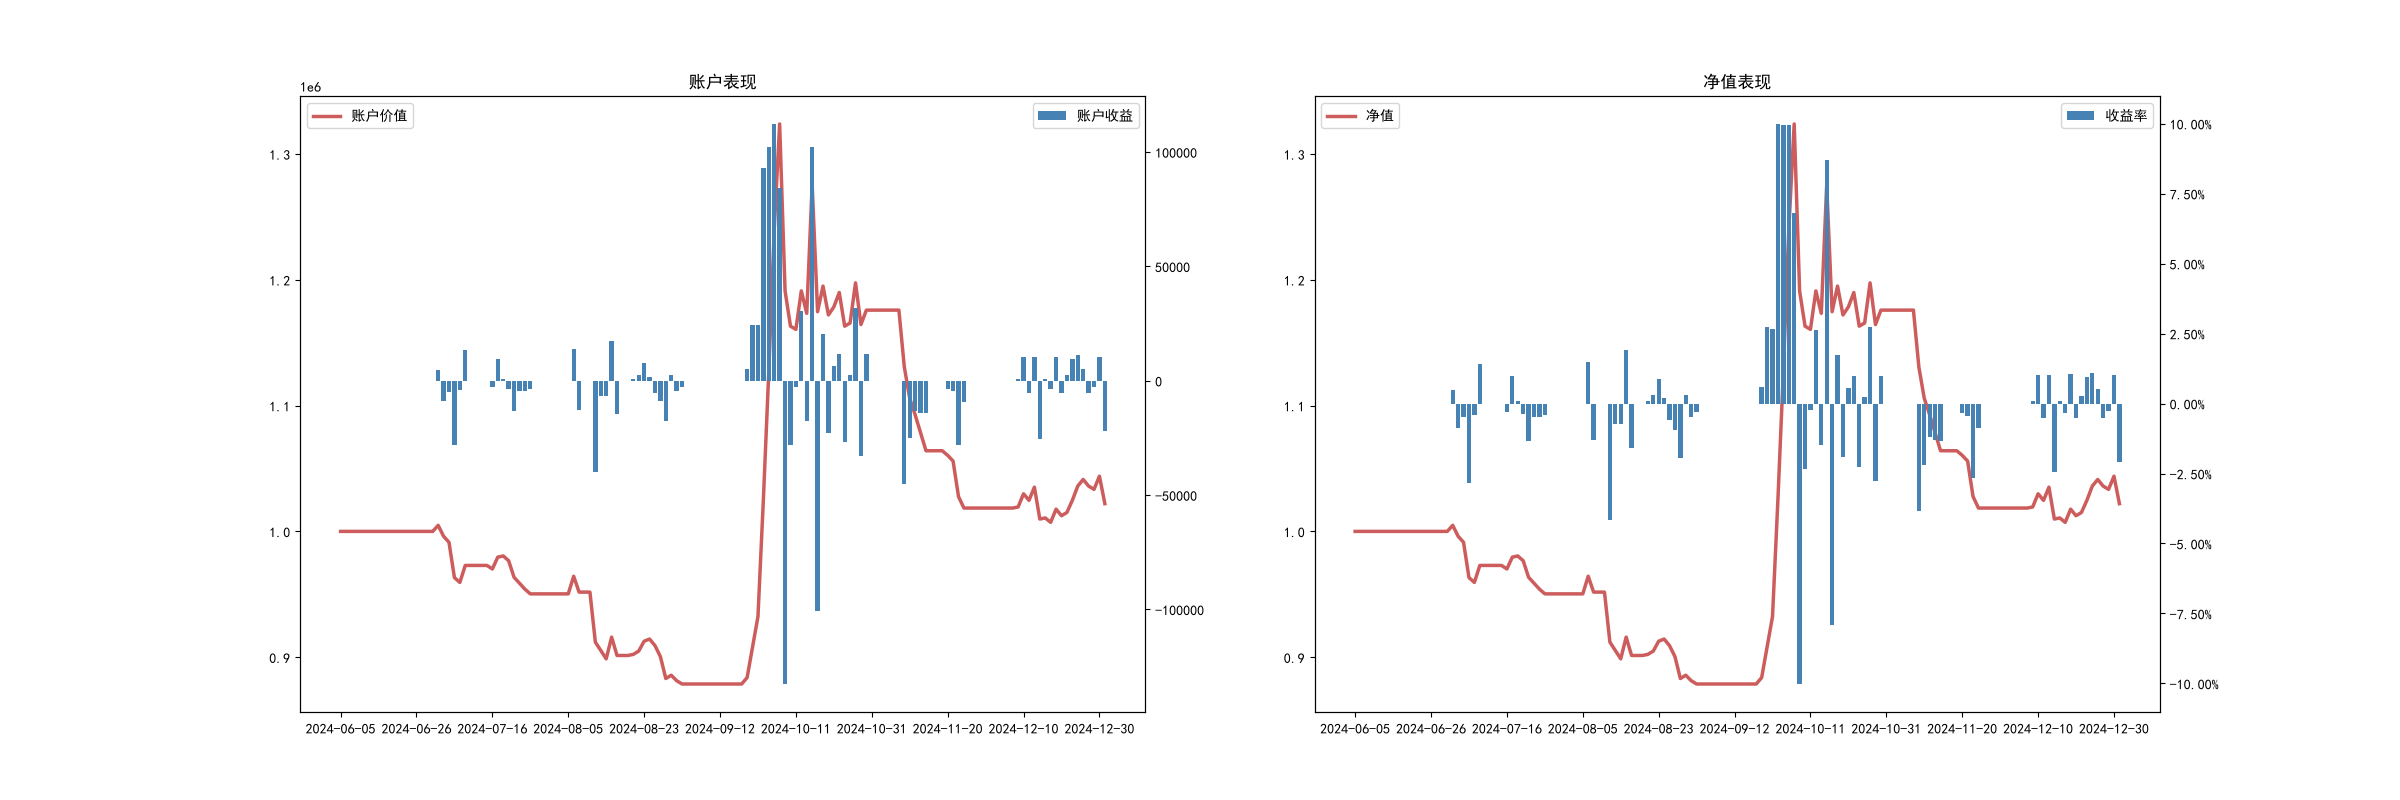

In [3]:
# 回测示例
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei']
matplotlib.rcParams['axes.unicode_minus'] = False# 正确显示负号
from IPython.display import HTML

from QuantStudio.Core.Node import DTLocalContext
from QuantStudio.Factor.Factor import FactorContext
from QuantStudio.Core.CalcEngine import Engine
from QuantStudio.BackTest.Strategy.Strategy import AccountStats, AccountReport

DTRuler = BSDB.getTradeDay(start_date=pd.to_datetime("2024-01-01"), end_date=pd.to_datetime("2024-12-31"))
DTs = DTRuler[100:]
SectionIDs = IDs = ["000001.SZ", "000002.SZ", "000003.SZ"]

# 策略报告
StrategyStats = AccountStats(account=Strategy, bmk_nv=None, args={"AccountSection": SectionIDs})
StrategyReport = AccountReport(account_node=StrategyStats)

NodeList = [StrategyReport]

with FactorContext(PIDList=["0"], DTRuler=DTRuler, SectionIDs=SectionIDs) as ctx:
    with Engine() as eng:
        Output = eng.run(NodeList, ctx, fwd_data_list=[DTLocalContext(DTs=DTs)])
display(HTML(Output[0]["Report"]))